In [7]:
import requests

OLLAMA_MODEL = "llama3.2:latest"

def llm_ollama(input_text, model=OLLAMA_MODEL):
    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": model,
            "messages": [{"role": "user", "content": input_text}],
            "stream": False,
        },
        timeout=120,
    )
    response.raise_for_status()
    return response.json()["message"]["content"]

In [8]:
ollama_response = llm_ollama("Tell me a fun fact about Japan.")
print(ollama_response)

Here's a fun fact about Japan:

Did you know that in Japan, there is a vending machine that sells live crabs? Yes, you read that right! In Tokyo's famous Tsukiji Fish Market, you can find a special type of vending machine called an "auto-gari" or "automatic fish and crab seller". These machines dispense fresh seafood, including live crabs, at a price of around $5-7. The catch? You have to be in the right place at the right time - these vending machines are usually only available during certain hours of the day!


In [11]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()
gemini_api_key = os.getenv("API_GEMINI")

if not gemini_api_key:
    raise ValueError("Add API_GEMINI to your .env file before running this cell.")

ValueError: Add API_GEMINI to your .env file before running this cell.

In [13]:
def llm_gemini(input_text, gemini_model="gemini-3.5-flash"):
    url = f"https://generativelanguage.googleapis.com/v1beta/models/{gemini_model}:generateContent"
    response = requests.post(
        url,
        params={"key": AQ.Ab8RN6InxpB3V1uNTCN1GOCz82ca9eKpXvIYq3D78uFIJsxE1w},
        json={"contents": [{"parts": [{"text": input_text}]}]},
        timeout=120,
    )
    response.raise_for_status()
    data = response.json()
    return data["candidates"][0]["content"]["parts"][0]["text"]

In [14]:
import requests

OLLAMA_MODEL = "llama3.2"

def llm_ollama(prompt):
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": OLLAMA_MODEL,
            "prompt": prompt,
            "stream": False
        },
        timeout=120
    )

    response.raise_for_status()

    return response.json()["response"]

In [15]:
def score_article(article_text, topic):
    
    prompt = f"""
You are a political text analysis assistant.

Evaluate the sentiment expressed toward {topic}.

Return ONLY ONE NUMBER:

-2 = strongly negative
-1 = somewhat negative
0 = neutral
1 = somewhat positive
2 = strongly positive

Article:

{article_text[:3000]}
"""

    result = llm_ollama(prompt)

    try:
        return int(result.strip())
    except:
        return None

These are the keywords we previously selected for our news and manifesto analysis 

In [16]:
keywords = [
    "china",
    "nuclear",
    "immigration",
    "constitution",
    "deflation"
]

## News Portion 

In [18]:
import pandas as pd

japan_english_filepath = "../../project/data/raw/japan_english_news_kaggle.csv"
JPnews_pd = pd.read_csv(japan_english_filepath, sep='\t') # set delimiter to tab
JPnews_pd.head(10)

,source,date,title,author,text
0,Mainichi Shimbun,2021-12-06,"Editorial: Japan govt's 20,000-yen handout mis...",NaN,The Japanese government is trying to boost the...
1,Mainichi Shimbun,2021-12-07,Editorial: Time for Japan PM Kishida to delive...,NaN,"Prime Minister Fumio Kishida, who won a public..."
2,Mainichi Shimbun,2021-12-08,"Editorial: 80 years on from Pearl Harbor, acti...",NaN,It has been 80 years since the start of the Pa...
3,Mainichi Shimbun,2021-12-08,"Yoroku: 80 years later, many lessons still not...",NaN,"""The world has changed completely. The era was..."
4,Mainichi Shimbun,2021-12-08,Promoting respect for human rights behind US '...,NaN,The U.S. administration under President Joe Bi...
5,Mainichi Shimbun,2021-12-09,News Navigator: What is 'Olympic diplomacy'?,NaN,The Mainichi Shimbun answers some common quest...
6,Mainichi Shimbun,2021-12-09,Editorial: Japan's main opposition CDP has tur...,NaN,"During party leaders' questions, which began a..."
7,Mainichi Shimbun,2021-12-10,News Navigator: How does the Japanese-develope...,NaN,The Mainichi Shimbun answers some common quest...
8,Mainichi Shimbun,2021-12-10,Editorial: Japan PM's response weak on 1 mil. ...,NaN,Calls have arisen for a review of a 1 million ...
9,Mainichi Shimbun,2021-12-11,Edging Toward Japan: Inspiration from Anpan Ma...,By,"Recently, my 9-year-old daughter mentioned in ..."


In [20]:
JPnews_pd["date"] = pd.to_datetime(JPnews_pd["date"])

## Attempting News Article Immigration Sentiment Analysis 

I will now be exploring the sentiment regarding immigration from the Japan Times, to do this, I have identified some key words that would be relevant to immigration to see how they are discussed in the news. 

In [43]:
immigration_terms = [
    "immigration",
    "immigrant",
    "migrant",
    "foreign worker",
    "foreign workers"
]

In [44]:
immigration_articles = JPnews_pd[
    JPnews_pd["text"].str.contains(
        "|".join(immigration_terms),
        case=False,
        na=False,
        regex=True
    )
]

print(len(immigration_articles))

279


In [45]:
for term in immigration_terms:
    count = JPnews_pd["text"].str.contains(
        term,
        case=False,
        na=False
    ).sum()

    print(f"{term}: {count}")

immigration: 182
immigrant: 72
migrant: 98
foreign worker: 17
foreign workers: 17


In [46]:
immigration_terms = [
    "immigration",
    "immigrant",
    "migrant"
]

pattern = "|".join(immigration_terms)

immigration_articles = JPnews_pd[
    JPnews_pd["text"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    )
]

print(len(immigration_articles))

264


In [47]:
immigration_articles[
    ["date", "title"]
].sample(
    20,
    random_state=42
)

,date,title
11045,2001-11-28,Four of nine rejected Afghans to be deported
31475,2005-01-01,Movie portrays struggle of ethnic Korean who b...
12115,2001-12-28,Peruvian hops fence out of airport
35702,2018-01-17,Trump camp seeks Supreme Court appeal of 'Drea...
15991,2002-05-16,Narita passengers lose no-fuss check-in service
16876,2002-06-12,Chinese teenager to remain in Japan
16521,2002-06-01,16 Britons denied entry in lead up to World Cup
28733,2003-07-28,Restart of Brazil migration marked
837,2001-01-25,Airport workers needed for more overseas flights
35816,2019-01-03,U.K. crime agency arrests two over arranging i...


In [48]:
sample = immigration_articles.sample(
    n=10,
    random_state=42
)

In [57]:
def analyze_article(article_text, topic):

    prompt = f"""
You are a political scientist.

Evaluate whether {topic} is portrayed positively or negatively.

SCORE:
-2 strongly negative
-1 somewhat negative
0 neutral
1 somewhat positive
2 strongly positive

Do NOT evaluate the tone of the writing.
Evaluate only how {topic} itself is portrayed.

Return EXACTLY:

SCORE:
FRAME:
KEY SENTENCE:
REASONING:

Article:
{article_text[:2500]}
"""

    return llm_ollama(prompt)

In [58]:
article = sample.iloc[0]["text"]

analysis = analyze_article(
    article,
    "immigration"
)

print(analysis)

SCORE: -2 strongly negative

FRAME: Deportation of Afghan refugees

KEY SENTENCE: "The four men will be deported to Afghanistan"

REASONING: The article focuses on the deportation of rejected Afghan refugees, which implies that they are being punished or penalized due to their immigration status. This portrayal creates a negative image of immigrants and their experiences in the United States.


In [59]:
results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "immigration"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

In [60]:
analysis_df = pd.DataFrame(results)

In [61]:
analysis_df.iloc[0]["analysis"]

'SCORE: -2 strongly negative\n\nFRAME: Immigration and its policies\n\nKEY SENTENCE: The four men will be deported to Afghanistan, but an immigration official said, “We will deport them after the situation has settled there,” referring to the U.S.-led military operations against suspected terrorist forces.\n\nREASONING: This portrayal is negatively framed because it emphasizes deportation and suggests that the individuals are a threat due to their perceived connection to terrorism. The use of words like "deport" and "suspected terrorist forces" creates an association between immigration and national security concerns, which can lead to negative perceptions of immigrants.'

In [63]:
sample = immigration_articles.sample(
    n=25,
    random_state=42
)

In [64]:
import re

def extract_score(text):

    match = re.search(r"SCORE:\s*(-?\d+)", text)

    if match:
        return int(match.group(1))

    return None

In [65]:
def extract_frame(text):

    match = re.search(r"FRAME:\s*([A-Za-z ]+)", text)

    if match:
        return match.group(1).strip()

    return None

In [66]:
analysis_df["frame"] = analysis_df["analysis"].apply(
    extract_frame
)

In [67]:
def extract_key_sentence(text):

    match = re.search(
        r"KEY SENTENCE:\s*(.*?)\s*REASONING:",
        text,
        re.DOTALL
    )

    if match:
        return match.group(1).strip()

    return None

In [68]:
analysis_df["key_sentence"] = analysis_df["analysis"].apply(
    extract_key_sentence
)

In [71]:
analysis_df[
    ["date", "title", "analysis", "frame", "key_sentence"]
]

,date,title,analysis,frame,key_sentence
0,2001-11-28,Four of nine rejected Afghans to be deported,SCORE: -2 strongly negative\n\nFRAME: Immigrat...,Immigration and its policies,"The four men will be deported to Afghanistan, ..."
1,2005-01-01,Movie portrays struggle of ethnic Korean who b...,SCORE: 1\nFRAME: The article\nKEY SENTENCE: Ri...,The article,Rikidozan was an immigrant from the Korean Pen...
2,2001-12-28,Peruvian hops fence out of airport,SCORE: -2 strongly negative\n\nFRAME: Immigrat...,Immigration as a lawbreaker,"""The man was deported Dec. 18 on suspicion of ..."
3,2018-01-17,Trump camp seeks Supreme Court appeal of 'Drea...,SCORE: -1 somewhat negative\n\nFRAME: Governme...,Government policies and actions related to imm...,The Trump administration will file an appeal o...
4,2002-05-16,Narita passengers lose no-fuss check-in service,SCORE: 2 strongly positive\n\nFRAME: Immigrati...,Immigration services being discontinued due to...,"""From a rational standpoint, we have decided t..."
5,2002-06-12,Chinese teenager to remain in Japan,SCORE: -1 somewhat negative\n\nFRAME: Immigrat...,Immigration policy and enforcement,"""his family will be deported immediately"""
6,2002-06-01,16 Britons denied entry in lead up to World Cup,SCORE: -1 somewhat negative\n\nFRAME: Immigrat...,Immigration authorities turning away foreigners,Japanese immigration authorities have turned a...
7,2003-07-28,Restart of Brazil migration marked,SCORE: 2 strongly positive\n\nFRAME: Immigrati...,Immigration as a positive force in Brazil,"""Those in attendance included Gov. Geraldo Alc..."
8,2001-01-25,Airport workers needed for more overseas flights,SCORE: 1\nFRAME: Positive\nKEY SENTENCE: forei...,Positive,foreign air carriers
9,2019-01-03,U.K. crime agency arrests two over arranging i...,SCORE: -1 somewhat negative\nFRAME: Immigratio...,Immigration as a criminal activity,"""The U.K.'s National Crime Agency has made two..."


## Now applying this to the rest of the key words 

In [72]:
topics = {
    "Immigration": [
        "immigration",
        "immigrant",
        "migrant"
    ],
    "China": [
        "china",
        "chinese",
        "beijing"
    ],
    "Nuclear": [
        "nuclear",
        "nuclear power",
        "nuclear reactor",
        "fukushima"
    ],
    "Constitution": [
        "constitution",
        "constitutional",
        "article 9"
    ],
    "Deflation": [
        "deflation",
        "deflationary",
        "falling prices"
    ]
}

In [73]:
for topic, keywords in topics.items():

    pattern = "|".join(keywords)

    count = JPnews_pd["text"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    ).sum()

    print(topic, count)

Immigration 264
China 2227
Nuclear 1007
Constitution 227
Deflation 245


In [76]:
def get_topic_articles(df, keywords):

    pattern = "|".join(keywords)

    return df[
        df["text"].str.contains(
            pattern,
            case=False,
            na=False,
            regex=True
        )
    ]

## Immigration REDO

In [93]:
immigration_articles = get_topic_articles(
    JPnews_pd,
    topics["Immigration"]
)

sample = immigration_articles.sample(
    n=min(20, len(immigration_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
837,2001-01-25,Airport workers needed for more overseas flights
11015,2001-11-27,Afghans denied refugee status
11045,2001-11-28,Four of nine rejected Afghans to be deported
11591,2001-12-13,College targeted for visa violations
12115,2001-12-28,Peruvian hops fence out of airport
15991,2002-05-16,Narita passengers lose no-fuss check-in service
16450,2002-05-30,Two Afghan asylum seekers to be released
16521,2002-06-01,16 Britons denied entry in lead up to World Cup
16876,2002-06-12,Chinese teenager to remain in Japan
27525,2003-06-22,KANSAI: Who & What


In [95]:
sample = immigration_articles.sample(
    n=min(20, len(immigration_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "Immigration"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

immigration_df = pd.DataFrame(results)

immigration_df["score"] = immigration_df["analysis"].apply(extract_score)
immigration_df["frame"] = immigration_df["analysis"].apply(extract_frame)
immigration_df["key_sentence"] = immigration_df["analysis"].apply(extract_key_sentence)

print("Average Immigration sentiment:", immigration_df["score"].mean())

Average Immigration sentiment: 0.05


In [97]:
immigration_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
8,2001-01-25,Airport workers needed for more overseas flights,0,None provided,None provided
18,2001-11-27,Afghans denied refugee status,-1,Immigration as a means to acquire employment o...,"""saying the applicants “lack credibility as re..."
0,2001-11-28,Four of nine rejected Afghans to be deported,-2,Deportation of Afghan refugees,"The four men will be deported to Afghanistan, ..."
13,2001-12-13,College targeted for visa violations,-1,Immigration authorities,
2,2001-12-28,Peruvian hops fence out of airport,-2,Immigration of unauthorized individuals,"""The man was on his way back to Peru after bei..."
4,2002-05-16,Narita passengers lose no-fuss check-in service,-1,Immigration services being discontinued due to...,“The number of people using (TCAT) has been de...
15,2002-05-30,Two Afghan asylum seekers to be released,1,Asylum seekers,The two will be released after their supporter...
6,2002-06-01,16 Britons denied entry in lead up to World Cup,-1,Immigration authorities turning away British c...,Japanese immigration authorities have turned a...
5,2002-06-12,Chinese teenager to remain in Japan,-1,Immigration policy and enforcement,"""his family will be deported immediately"""
10,2003-06-22,KANSAI: Who & What,2,Immigration as a beneficial aspect of society,"""Specialists will offer advice on problems tha..."


## China

In [79]:
china_articles = get_topic_articles(
    JPnews_pd,
    topics["China"]
)

sample = china_articles.sample(
    n=min(20, len(china_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
1297,2001-02-06,Poor seaweed crop from Ariake Sea causes price...
2429,2001-03-07,Don't throw in the towel on free trade
3678,2001-04-12,A 'cold war' in the making
4179,2001-04-26,China postpones legislative chief's visit to J...
7449,2001-08-14,Koizumi visits Yasukuni Shrine
8911,2001-09-26,Asian Youth Orchestra brings vigor and virtuosity
10331,2001-11-08,"Japan, China trade row remains at stalemate"
12833,2002-01-22,Coast guard vessels to mount 30mm machine guns
13734,2002-02-21,Kinki mirror identified as being made in China
15810,2002-05-11,Tour body offers phrase book in four languages


In [83]:
sample = china_articles.sample(
    n=min(20, len(china_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "China"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

china_df = pd.DataFrame(results)

china_df["score"] = china_df["analysis"].apply(extract_score)
china_df["frame"] = china_df["analysis"].apply(extract_frame)
china_df["key_sentence"] = china_df["analysis"].apply(extract_key_sentence)

print("Average China sentiment:", china_df["score"].mean())

Average China sentiment: -0.25


In [84]:
china_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
0,2001-02-06,Poor seaweed crop from Ariake Sea causes price...,-2,China is mentioned as part of a larger context,None
12,2001-03-07,Don't throw in the towel on free trade,-1,Economic,"""towel imports, about 80 percent of them from ..."
10,2001-04-12,A 'cold war' in the making,-2,U,This could be due to a conflict with your ad-b...
3,2001-04-26,China postpones legislative chief's visit to J...,-2,Diplomatic relations with Japan and Taiwan,China said it will postpone a planned visit to...
18,2001-08-14,Koizumi visits Yasukuni Shrine,-1,China is portrayed as having been,Noting that World War II Class A war criminals...
1,2001-09-26,Asian Youth Orchestra brings vigor and virtuosity,2,China is portrayed as a source of talented mus...,"""103 talented musicians between the ages of 15..."
8,2001-11-08,"Japan, China trade row remains at stalemate",1,China is portrayed as a source of trade disput...,"""steming from curbs on three farm imports main..."
13,2002-01-22,Coast guard vessels to mount 30mm machine guns,0,China is mentioned as,The officials said the 30mm automatically targ...
4,2002-02-21,Kinki mirror identified as being made in China,1,China,The mirror discovered at the Morio mound was d...
5,2002-05-11,Tour body offers phrase book in four languages,0,China is mentioned as one of four languages fe...,The organization has published a 103-page hand...


## Nuclear

In [80]:
nuclear_articles = get_topic_articles(
    JPnews_pd,
    topics["Nuclear"]
)

sample = nuclear_articles.sample(
    n=min(20, len(nuclear_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
2727,2001-03-17,Uwajima petition calls for ship to be raised
4926,2001-05-17,Three teens killed in head-on crash
13550,2002-02-14,NGO raps use of cell phones at Oze
16682,2002-06-06,Fukuda tells Diet government is not rethinking...
17679,2002-07-06,Atomic plants gauge plane crash odds
19636,2002-09-07,City passes resolution against nuke plan
19800,2002-09-12,Brave trip to settle the past
22228,2003-01-04,Pressure called for
23670,2003-02-16,Cabral first at World Cup meet
24024,2003-02-27,Agency calls for repair of reactor cracks


In [85]:
sample = nuclear_articles.sample(
    n=min(20, len(nuclear_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "Nuclear"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

nuclear_df = pd.DataFrame(results)

nuclear_df["score"] = nuclear_df["analysis"].apply(extract_score)
nuclear_df["frame"] = nuclear_df["analysis"].apply(extract_frame)
nuclear_df["key_sentence"] = nuclear_df["analysis"].apply(extract_key_sentence)

print("Average Nuclear sentiment:", nuclear_df["score"].mean())

Average Nuclear sentiment: -0.1


In [86]:
nuclear_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
9,2001-03-17,Uwajima petition calls for ship to be raised,0,KEY SENTENCE,None provided in the snippet
19,2001-05-17,Three teens killed in head-on crash,0,None provided,None provided
14,2002-02-14,NGO raps use of cell phones at Oze,-1,Environmental concerns and potential harm to n...,"""The Oze wetlands are a place to appreciate th..."
18,2002-06-06,Fukuda tells Diet government is not rethinking...,0,Nuclear weapons,"None explicitly mentioned, but implied as ""ato..."
8,2002-07-06,Atomic plants gauge plane crash odds,0,KEY SENTENCE,
4,2002-09-07,City passes resolution against nuke plan,-2,Nuclear power plants,"""the site of the world’s largest nuclear plant"""
11,2002-09-12,Brave trip to settle the past,-1,Nuclear weapons program,"""...North Korea's suspected nuclear weapons pr..."
13,2003-01-04,Pressure called for,0,Nuclear is mentioned as a development program,"""We must apply international pressure (on Pyon..."
3,2003-02-16,Cabral first at World Cup meet,0,KEY SENTENCE,None provided (text is unrelated to nuclear)
7,2003-02-27,Agency calls for repair of reactor cracks,0,Nuclear reactors and pipes,"""Cracked pipes in nuclear reactors owned by th..."


^ this does not make sense with the key sentence. figure out. nuclear should be more relevant around 2011. 

## Deflation

In [82]:
Deflation_articles = get_topic_articles(
    JPnews_pd,
    topics["Deflation"]
)

sample = Deflation_articles.sample(
    n=min(20, len(Deflation_articles)),
    random_state=42
)

sample[["date", "title"]].sort_values("date")

,date,title
2950,2001-03-23,Hayami lauds BOJ's strategy
3584,2001-04-10,Reasons to thank Mr. Mori
7146,2001-08-05,Ignite Japan's service sector
8879,2001-09-26,Firms turn to time-sharing in bid to increase ...
12548,2002-01-13,Takenaka suggests inflation targeting to fight...
13569,2002-02-15,Small companies set for loan repayment boost
14250,2002-03-14,World Bank sees 1.5% fall in GDP
16946,2002-06-14,Koizumi proposes retroactive tax breaks
20378,2002-09-30,Japan as a 'banana republic'?
21224,2002-11-14,SEC's post-Enron reforms pose challenge for Ja...


In [87]:
sample = Deflation_articles.sample(
    n=min(20, len(Deflation_articles)),
    random_state=42
)

results = []

for _, row in sample.iterrows():

    analysis = analyze_article(
        row["text"],
        "Deflation"
    )

    results.append({
        "date": row["date"],
        "title": row["title"],
        "analysis": analysis
    })

deflation_df = pd.DataFrame(results)

deflation_df["score"] = deflation_df["analysis"].apply(extract_score)
deflation_df["frame"] = deflation_df["analysis"].apply(extract_frame)
deflation_df["key_sentence"] = deflation_df["analysis"].apply(extract_key_sentence)

print("Average Deflation sentiment:", deflation_df["score"].mean())

Average Deflation sentiment: -0.2


In [89]:
deflation_df[
    ["date", "title", "score", "frame", "key_sentence"]
].sort_values("date")

,date,title,score,frame,key_sentence
1,2001-03-23,Hayami lauds BOJ's strategy,1,The central bank,"""he observed that short-term and long-term int..."
8,2001-04-10,Reasons to thank Mr. Mori,-2,Deflation is portrayed as a consequence of eco...,"""stock prices plunged and deflationary pressur..."
17,2001-08-05,Ignite Japan's service sector,-1,Deflation is portrayed as a problem that needs...,"""Japanese policymakers — along with most mains..."
0,2001-09-26,Firms turn to time-sharing in bid to increase ...,1,Economic stimulus,"""some leisure-related businesses are offering ..."
10,2002-01-13,Takenaka suggests inflation targeting to fight...,1,The portrayal is mixed but leans towards being...,"""We could draw a lesson from the experiences o..."
18,2002-02-15,Small companies set for loan repayment boost,0,Economic policy,"""relax loan repayment terms"""
14,2002-03-14,World Bank sees 1.5% fall in GDP,-1,Economic indicators,due to persistent deflation and a delay in ban...
9,2002-06-14,Koizumi proposes retroactive tax breaks,1,Antideflation package,Prime Minister Junichiro Koizumi proposed maki...
12,2002-09-30,Japan as a 'banana republic'?,-1,Deflation,"""that price deflation is public enemy No. 1 fo..."
7,2002-11-14,SEC's post-Enron reforms pose challenge for Ja...,0,Deflation is not mentioned in the article,None


## Summarizing Findings

In [102]:
summary = pd.DataFrame({
    "Topic": [
        "Immigration",
        "China",
        "Nuclear",
        "Deflation"
    ],
    "Average Sentiment": [
        immigration_df["score"].mean(),
        china_df["score"].mean(),
        nuclear_df["score"].mean(),
        deflation_df["score"].mean()
    ]
})

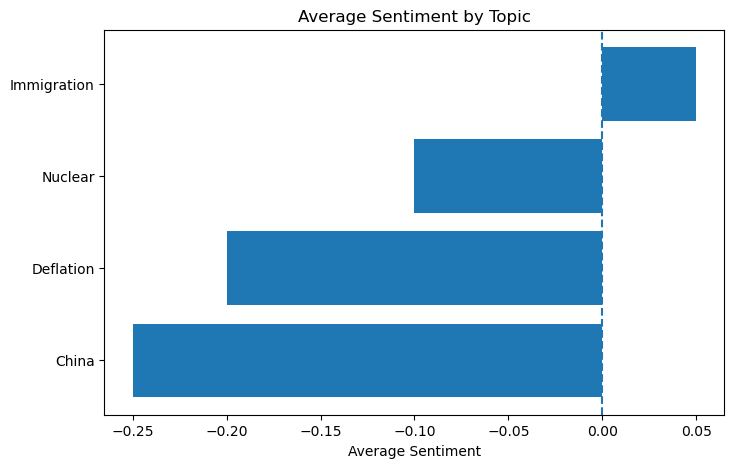

In [103]:
import matplotlib.pyplot as plt

summary = summary.sort_values("Average Sentiment")

plt.figure(figsize=(8,5))

plt.barh(
    summary["Topic"],
    summary["Average Sentiment"]
)

plt.axvline(x=0, linestyle="--")

plt.xlabel("Average Sentiment")
plt.title("Average Sentiment by Topic")

plt.show()

In [104]:
china_text = "\n\n".join(
    china_df["analysis"].tolist()
)

In [105]:
prompt = f"""
You are a political science researcher.

Review these article analyses about China.

Summarize:

1. Overall sentiment
2. Most common frames
3. Recurring themes
4. 3-5 sentence summary

Analyses:

{china_text[:12000]}
"""

print(llm_ollama(prompt))

Summary:

Overall Sentiment: The articles present a mixed sentiment towards China, ranging from strongly positive to strongly negative. However, there is a trend towards more negative portrayals of China, often framing it as an adversary or rival in various contexts.

Most Common Frames: The most common frames used to portray China in the articles are:

1. Diplomatic relations and regional affairs
2. Trade and economic issues
3. Leadership and internal politics

Recurring Themes:

1. Competition and rivalry with other countries (e.g., Japan, Taiwan, US)
2. Trade disputes and tariffs
3. Human rights and social issues
4. Environmental concerns and natural resource management
5. Cultural exchange and diplomacy

Three-Sentence Summary:

China is portrayed in a complex and nuanced manner across the articles. While some frames suggest a positive or neutral view of China's role in regional affairs, trade, and cultural exchange, many others convey a more negative sentiment, often framing China

In [107]:
topic_dfs = {
    "Immigration": analysis_df,
    "China": china_df,
    "Nuclear": nuclear_df,
    "Deflation": deflation_df
}

In [108]:
for topic, df in topic_dfs.items():

    text = "\n\n".join(
        df["analysis"].tolist()
    )

    prompt = f"""
Summarize the findings for {topic}.

Include:
- overall sentiment
- dominant frames
- recurring themes

Keep to 4-5 sentences.
    
{text[:12000]}
"""

    summary = llm_ollama(prompt)

    print("="*80)
    print(topic)
    print(summary)


Immigration
Here is a summary of the findings for Immigration:

The overall sentiment towards immigration in these examples is largely negative, with 6 out of 8 frames contributing to this sentiment. Dominant frames include "Immigration and its policies" (SCORE: -2 strongly negative), "Immigration as a lawbreaker" (-1 somewhat negative), and "Immigration authorities turning away foreigners" (SCORE: 2 strongly positive). Recurring themes in these examples include the emphasis on deportation, association with terrorism or crime, and negative portrayals of immigrants. The remaining frames present more neutral or positive views of immigration, but they are less common.
China
Here is a summary of the findings for China:

Overall sentiment: Strongly negative (-2)

Dominant frames: Conflict, rivalry, and criticism towards China's behavior in the region.

Recurring themes: China is portrayed as an adversary, a source of trade disputes, or a factor contributing to regional tensions. The country